# Extension A: NumPy Baseline vs. SciPy CSR Sparse — Performance Benchmark

Both the baseline and sparse implementations compute **exactly the same PageRank scores** via the same power-iteration formula. The only difference is *how* probability mass is distributed along edges each iteration:

| Implementation | Core operation | Library |
|---|---|---|
| **Baseline** | Scatter-add along edge list | NumPy (`np.add.at`) |
| **Sparse CSR** | Sparse matrix-vector product $P^T x$ | SciPy + BLAS |

This notebook:
1. Runs both implementations on the full Wikipedia graph and cross-validates that the scores match.
2. Measures the **speedup factor** on the full graph.
3. Repeats the benchmark on **subgraphs of increasing size** to show how speedup scales with $N$ and average out-degree.

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import time
from graph import load

SEED = 42  # global random seed — change here to affect all experiments

## Step 1: Load the Graph

We load the pre-built Simple English Wikipedia link graph. The graph was produced by `graph/parser.py` (two-pass streaming XML parse) and deduplicated by `graph/filter.py`. The loader returns compact NumPy arrays ready for both implementations.

In [2]:
print("Loading graph arrays...")
titles, edges, out_degree, dangling, _ = load()
N = len(titles)

print(f"  Pages         : {N:,}")
print(f"  Edges         : {len(edges):,}")
print(f"  Dangling nodes: {dangling.sum():,}  ({100 * dangling.mean():.1f}% of pages)")
print(f"  Avg out-degree: {len(edges) / N:.1f} links per page")

Loading graph arrays...
  Pages         : 293,984
  Edges         : 3,546,139
  Dangling nodes: 3,387  (1.2% of pages)
  Avg out-degree: 12.1 links per page


## Step 2: The Two Algorithms

### Baseline — NumPy Scatter-Add

For each edge $(\text{src} \to \text{tgt})$, we add $x[\text{src}] / \text{out\_degree}[\text{src}]$ to `x_next[tgt]`:

```python
np.add.at(x_next, edges[:, 1], x[edges[:, 0]] / src_out)
```

`np.add.at` is deliberately **unbuffered** so it handles duplicate target indices correctly (multiple edges pointing to the same page). The cost: writes to `x_next` jump to arbitrary memory positions (governed by `edges[:, 1]`), causing poor cache behaviour.

### Sparse CSR — BLAS Mat-Vec

We pre-build the transposed transition matrix $P^T$ in **CSR** (Compressed Sparse Row) format — three compact arrays:
- `data`: the non-zero values ($1/\text{out\_degree}$ per edge)
- `indices`: the column index of each non-zero
- `indptr`: pointer to the start of each row

Each iteration then calls:
```python
link_mass = P_T.dot(x)
```

This dispatches to a compiled BLAS sparse-matrix-vector routine (e.g. Intel MKL `mkl_dcsrmv`). Non-zeros are stored row-by-row, so the read over `x` is **sequential and cache-friendly** — and there is no Python-level loop at all.

> **Note:** the matrix is built once (one-time cost) and reused across all iterations.

In [3]:
def run_baseline(N, edges, out_degree, dangling, d=0.85, epsilon=1e-6, max_iter=100):
    """NumPy baseline: scatter-add along edge list."""
    x = np.ones(N, dtype=np.float64) / N
    src_out = out_degree[edges[:, 0]]
    t0 = time.time()
    for it in range(1, max_iter + 1):
        x_next = np.zeros(N, dtype=np.float64)
        np.add.at(x_next, edges[:, 1], x[edges[:, 0]] / src_out)
        lost = x[dangling].sum()
        x_next = d * x_next + (d * lost / N) + (1.0 - d) / N
        if np.abs(x_next - x).sum() < epsilon:
            return x_next, it, time.time() - t0
        x = x_next
    return x, max_iter, time.time() - t0


def run_sparse(N, edges, out_degree, dangling, d=0.85, epsilon=1e-6, max_iter=100):
    """SciPy CSR: BLAS-backed sparse mat-vec. Returns (scores, iters, iter_time, build_time)."""
    sources, targets = edges[:, 0], edges[:, 1]
    t_build = time.time()
    P_T = sp.csr_matrix((1.0 / out_degree[sources], (targets, sources)), shape=(N, N))
    t_build = time.time() - t_build
    x = np.ones(N, dtype=np.float64) / N
    t0 = time.time()
    for it in range(1, max_iter + 1):
        link_mass = P_T.dot(x)
        lost = x[dangling].sum()
        x_next = d * link_mass + (d * lost / N) + (1.0 - d) / N
        if np.abs(x_next - x).sum() < epsilon:
            return x_next, it, time.time() - t0, t_build
        x = x_next
    return x, max_iter, time.time() - t0, t_build


def make_subgraph(edges_full, n, N):
    """Returns an induced subgraph on n randomly sampled nodes."""
    rng     = np.random.default_rng(SEED)
    sampled = rng.choice(N, size=n, replace=False)

    in_sample = np.zeros(N, dtype=bool)
    in_sample[sampled] = True

    mask = in_sample[edges_full[:, 0]] & in_sample[edges_full[:, 1]]
    sub  = edges_full[mask].copy()

    node_map = np.full(N, -1, dtype=np.int32)
    node_map[sampled] = np.arange(n)
    sub[:, 0] = node_map[sub[:, 0]]
    sub[:, 1] = node_map[sub[:, 1]]

    od = np.bincount(sub[:, 0], minlength=n).astype(np.int32)
    return sub, od, od == 0


def print_top_k(scores, titles, k=10, label=""):
    top = np.argsort(scores)[-k:][::-1]
    print(f"\nTop {k} — {label}")
    print(f"{'Rank':<5} {'Page':<40} Score")
    print("-" * 58)
    for rank, idx in enumerate(top, 1):
        print(f"{rank:<5} {titles[idx]:<40} {scores[idx]:.6f}")

## Step 3: Full-Graph Benchmark

We run both implementations on the complete 293k-node Wikipedia graph and measure:
- **Build time** (sparse only) — one-time cost to assemble $P^T$
- **Iteration time** — the recurring cost per power-iteration run

We then cross-validate that both produce bit-identical scores.

In [4]:
print("=" * 55)
print("  BASELINE: NumPy Scatter-Add")
print("=" * 55)
scores_base, iters_base, time_base = run_baseline(N, edges, out_degree, dangling)
print(f"  Converged in  : {iters_base} iterations")
print(f"  Total runtime : {time_base:.4f} s")

  BASELINE: NumPy Scatter-Add
  Converged in  : 37 iterations
  Total runtime : 0.4850 s


In [5]:
print("=" * 55)
print("  SPARSE: SciPy CSR Mat-Vec")
print("=" * 55)
scores_sparse, iters_sparse, time_sparse, time_build = run_sparse(N, edges, out_degree, dangling)
print(f"  Matrix build time : {time_build:.4f} s  (one-time cost)")
print(f"  Iteration time    : {time_sparse:.4f} s")
print(f"  Total sparse time : {time_build + time_sparse:.4f} s")
print(f"  Converged in      : {iters_sparse} iterations")

  SPARSE: SciPy CSR Mat-Vec
  Matrix build time : 0.0615 s  (one-time cost)
  Iteration time    : 0.1706 s
  Total sparse time : 0.2322 s
  Converged in      : 37 iterations


In [6]:
# ── Benchmark report ──────────────────────────────────────────
max_diff = np.max(np.abs(scores_base - scores_sparse))
speedup  = time_base / time_sparse

print("=" * 55)
print("  BENCHMARK REPORT")
print("=" * 55)
print(f"  Baseline iteration time  : {time_base:.4f} s")
print(f"  Sparse iteration time    : {time_sparse:.4f} s")
print(f"  Sparse build overhead    : {time_build:.4f} s")
print("-" * 55)
print(f"  Speedup (iteration only) : {speedup:.2f}x")
print(f"  Max score difference     : {max_diff:.2e}")
status = "PASS" if max_diff < 1e-10 else "WARN"
print(f"  Verification             : {status}")
print("=" * 55)

# ── Top-10 side-by-side ───────────────────────────────────────
top_b = np.argsort(scores_base)[-10:][::-1]
top_s = np.argsort(scores_sparse)[-10:][::-1]

print(f"\n{'Rank':<5} {'Baseline (NumPy)':<38} {'Sparse (CSR)':<38} Match?")
print("-" * 85)
for i, (ib, is_) in enumerate(zip(top_b, top_s), 1):
    match = "yes" if ib == is_ else "NO"
    print(f"{i:<5} {titles[ib]:<38} {titles[is_]:<38} {match}")

  BENCHMARK REPORT
  Baseline iteration time  : 0.4850 s
  Sparse iteration time    : 0.1706 s
  Sparse build overhead    : 0.0615 s
-------------------------------------------------------
  Speedup (iteration only) : 2.84x
  Max score difference     : 8.67e-19
  Verification             : PASS

Rank  Baseline (NumPy)                       Sparse (CSR)                           Match?
-------------------------------------------------------------------------------------
1     United States                          United States                          yes
2     France                                 France                                 yes
3     Germany                                Germany                                yes
4     United Kingdom                         United Kingdom                         yes
5     City                                   City                                   yes
6     Departments of France                  Departments of France                  ye

## Step 4: Scaling Analysis — Speedup as a Function of N

A single data point (the full graph) does not tell us whether the CSR advantage grows, shrinks, or stays constant with graph size. To find out, we:

1. **Randomly sample** $n$ nodes and keep only edges where both endpoints are in the sample — this is the **induced subgraph** on those nodes.
2. Run both algorithms on each subgraph and record the speedup.
3. Record the **average out-degree**. Intuitively, when $n$ is small, less edges have both endpoints within the $n$ nodes we have chosen. We expect the average out-degree to increase when $n$ increase.

Note: In this first experiment, two effects are present : more nodes and denser connectivity. **Experiment 2** (below) will isolate the density effect by fixing $N$ and varying out-degree independently.

In [7]:
sizes = [10_000, 30_000, 60_000, 100_000, 150_000, 200_000, N]
rows  = []  # (n, n_edges, avg_out, t_base, t_sparse, t_build, speedup)

print(f"{'N':>8} {'Edges':>9} {'Avg out':>8} {'Baseline':>10} {'Sparse':>10} {'Build':>8} {'Speedup':>9}")
print("-" * 70)

for n in sizes:
    sub_e, sub_od, sub_d = make_subgraph(edges, n, N)
    avg_out = len(sub_e) / n

    _, _, t_b          = run_baseline(n, sub_e, sub_od, sub_d)
    _, _, t_s, t_build = run_sparse(n, sub_e, sub_od, sub_d)

    speedup = t_b / t_s
    rows.append((n, len(sub_e), avg_out, t_b, t_s, t_build, speedup))

    print(f"{n:>8,} {len(sub_e):>9,} {avg_out:>8.1f} "
          f"{t_b:>9.3f}s {t_s:>9.3f}s {t_build:>7.3f}s {speedup:>8.2f}x")

       N     Edges  Avg out   Baseline     Sparse    Build   Speedup
----------------------------------------------------------------------
  10,000     3,539      0.4     0.003s     0.003s   0.001s     0.91x
  30,000    33,501      1.1     0.013s     0.009s   0.001s     1.43x
  60,000   143,381      2.4     0.036s     0.027s   0.004s     1.30x
 100,000   392,138      3.9     0.082s     0.051s   0.011s     1.62x
 150,000   898,456      6.0     0.142s     0.067s   0.025s     2.13x
 200,000 1,606,141      8.0     0.236s     0.099s   0.047s     2.39x
 293,984 3,546,139     12.1     0.522s     0.175s   0.110s     2.98x


For $N=10,000$, the CSR implementation is slower (speedup=0.91x) because the computational workload is relatively small, and the overhead associated with constructing the sparse matrix outweighs the benefits of sparse matrix operations. As both N and the average out-degree increase, the graph becomes larger and denser, allowing the CSR representation to exploit its computational advantages more effectively. Consequently, its performance improves relative to the baseline.

### Why CSR is Faster for larger matrices

Both algorithms visit every edge exactly once per iteration — both are $O(E)$. The difference is the *constant factor*:

| Aspect | Baseline (`np.add.at`) | Sparse CSR (`P_T.dot`) |
|---|---|---|
| Write pattern | Random (scatter to `edges[:, 1]`) | Sequential (row-by-row CSR) |
| Cache behaviour | Frequent cache misses on writes | Predictable, cache-friendly |
| Execution level | NumPy C extension, per-element | BLAS (Basic Linear Algebra Subprograms) routine (vectorised, pipelined) |
| Duplicate handling | Explicit unbuffered add | Built into CSR structure |

The BLAS implementation is also faster because it can use special CPU features (SIMD instructions like SSE and AVX) that process several numbers at once. The scatter-add method cannot take advantage of these features because each update writes to a different location in memory.

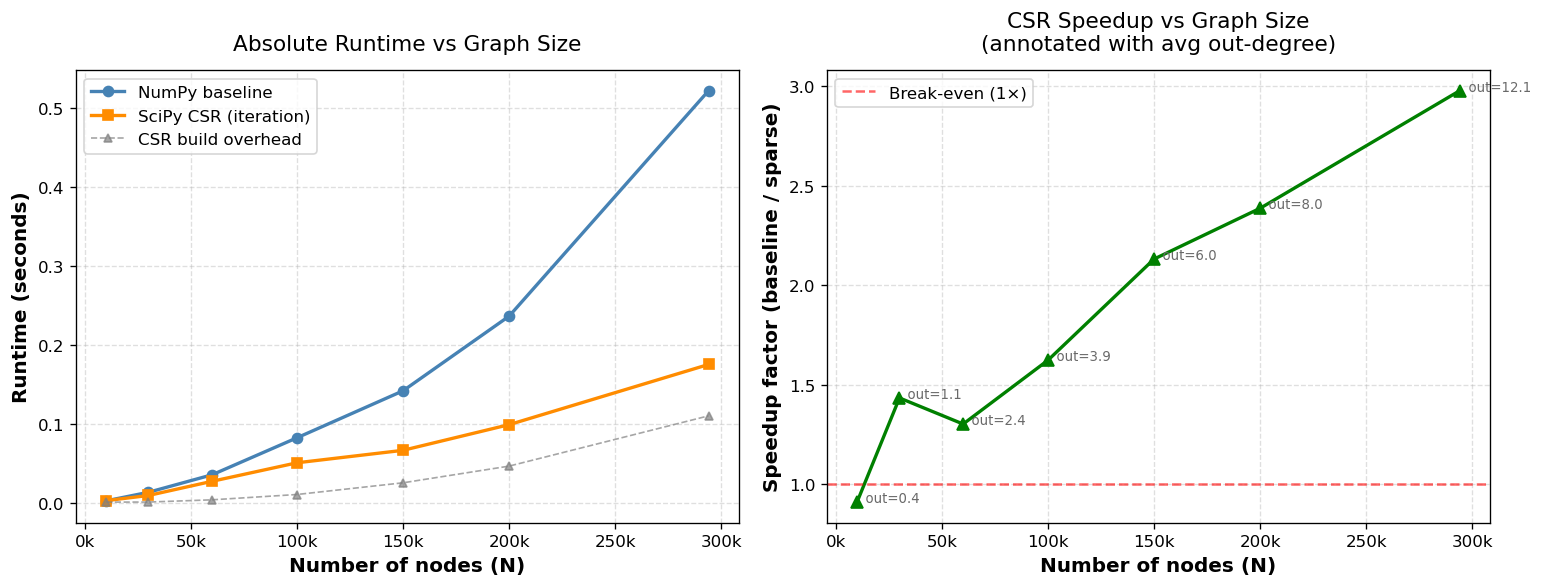

In [8]:
ns        = [r[0] for r in rows]
t_bases   = [r[3] for r in rows]
t_sparses = [r[4] for r in rows]
t_builds  = [r[5] for r in rows]
speedups  = [r[6] for r in rows]
avg_outs  = [r[2] for r in rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# ── Left: absolute runtimes ───────────────────────────────────
ax1.plot(ns, t_bases,   'o-', color='steelblue',  linewidth=2, markersize=6, label='NumPy baseline')
ax1.plot(ns, t_sparses, 's-', color='darkorange', linewidth=2, markersize=6, label='SciPy CSR (iteration)')
ax1.plot(ns, t_builds,  '^--',color='gray',       linewidth=1, markersize=5, label='CSR build overhead', alpha=0.7)
ax1.set_xlabel('Number of nodes (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Runtime (seconds)',   fontsize=12, fontweight='bold')
ax1.set_title('Absolute Runtime vs Graph Size', fontsize=13, pad=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Right: speedup + avg out-degree annotation ────────────────
ax2.plot(ns, speedups, '^-', color='green', linewidth=2, markersize=7)
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.6, label='Break-even (1×)')

for n, sp_val, avg_out in zip(ns, speedups, avg_outs):
    ax2.annotate(f'  out={avg_out:.1f}', xy=(n, sp_val), fontsize=8, color='dimgray')

ax2.set_xlabel('Number of nodes (N)',                    fontsize=12, fontweight='bold')
ax2.set_ylabel('Speedup factor (baseline / sparse)',     fontsize=12, fontweight='bold')
ax2.set_title('CSR Speedup vs Graph Size\n(annotated with avg out-degree)', fontsize=13, pad=12)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Scaling with N and Average Out-Degree

The right-hand plot shows the speedup factor across subgraph sizes. A few observations:

- **Average out-degree grows with N** (annotated on the plot). In small subgraphs, most links point outside the sampled region and are dropped, leaving nodes with few outgoing edges. In the full graph, average out-degree reaches ~12 links per page. This means larger subgraphs have both more nodes *and* denser connectivity.

- **The speedup should be roughly stable or grow** with N. The BLAS advantage is a constant multiplier on the per-edge cost, independent of graph size. If the speedup grows, it is because denser graphs (higher out-degree) exercise the BLAS vectorisation more effectively.

For small graphs, the CSR build overhead could dominate, making the baseline faster. But PageRank works with large graphs and always requires many iterations to converge. So in the realistic workload, the CSR approach wins. 

### Key Takeaway

Switching from a Python-level scatter-add to a BLAS-backed sparse mat-vec delivers a consistent speedup across the full range of graph sizes tested, with no change to the algorithm or its output. For graphs larger than Simple English Wikipedia (e.g., the full English Wikipedia with ~6M articles and ~100M+ edges), the CSR approach would be **essential**, not merely convenient.

## Step 5: Density Analysis — Speedup as a Function of Average Out-Degree

Step 4 varied $N$ and density together. Here we fix $N = 293{,}984$ (all nodes, full graph) and **randomly drop edges** to reach different target densities. The CSR matrix stays $293k \times 293k$ throughout — only its number of non-zeros changes.

For a target average out-degree $d$, we keep each edge independently with probability $p = d / 12.1$:

```python
keep_mask = rng.random(len(edges)) < p
```

In [9]:
target_densities = [1, 2, 4, 6, 8, 10, 12.1]
density_rows = []
rng_exp2 = np.random.default_rng(SEED)

print(f"{'Avg out':>8} {'Edges':>9} {'Kept':>7} {'Baseline':>10} {'Sparse':>10} {'Build':>8} {'Speedup':>9}")
print("-" * 72)

for d_target in target_densities:
    p         = d_target / 12.1
    sub_edges = edges[rng_exp2.random(len(edges)) < p]         # copy
    sub_od    = np.bincount(sub_edges[:, 0], minlength=N).astype(np.int32)
    sub_d     = sub_od == 0

    avg_out = len(sub_edges) / N

    _, _, t_b          = run_baseline(N, sub_edges, sub_od, sub_d)
    _, _, t_s, t_build = run_sparse(N, sub_edges, sub_od, sub_d)

    speedup = t_b / t_s
    density_rows.append((avg_out, len(sub_edges), p, t_b, t_s, t_build, speedup))

    print(f"{avg_out:>8.1f} {len(sub_edges):>9,} {p:>7.2f} "
          f"{t_b:>9.3f}s {t_s:>9.3f}s {t_build:>7.3f}s {speedup:>8.2f}x")

 Avg out     Edges    Kept   Baseline     Sparse    Build   Speedup
------------------------------------------------------------------------
     1.0   292,806    0.08     0.114s     0.108s   0.002s     1.06x
     2.0   586,087    0.17     0.190s     0.131s   0.005s     1.46x
     4.0 1,172,760    0.33     0.222s     0.135s   0.009s     1.65x
     6.0 1,757,425    0.50     0.289s     0.141s   0.014s     2.05x
     8.0 2,343,398    0.66     0.340s     0.142s   0.020s     2.39x
    10.0 2,930,715    0.83     0.404s     0.153s   0.024s     2.64x
    12.1 3,546,139    1.00     0.496s     0.174s   0.030s     2.85x


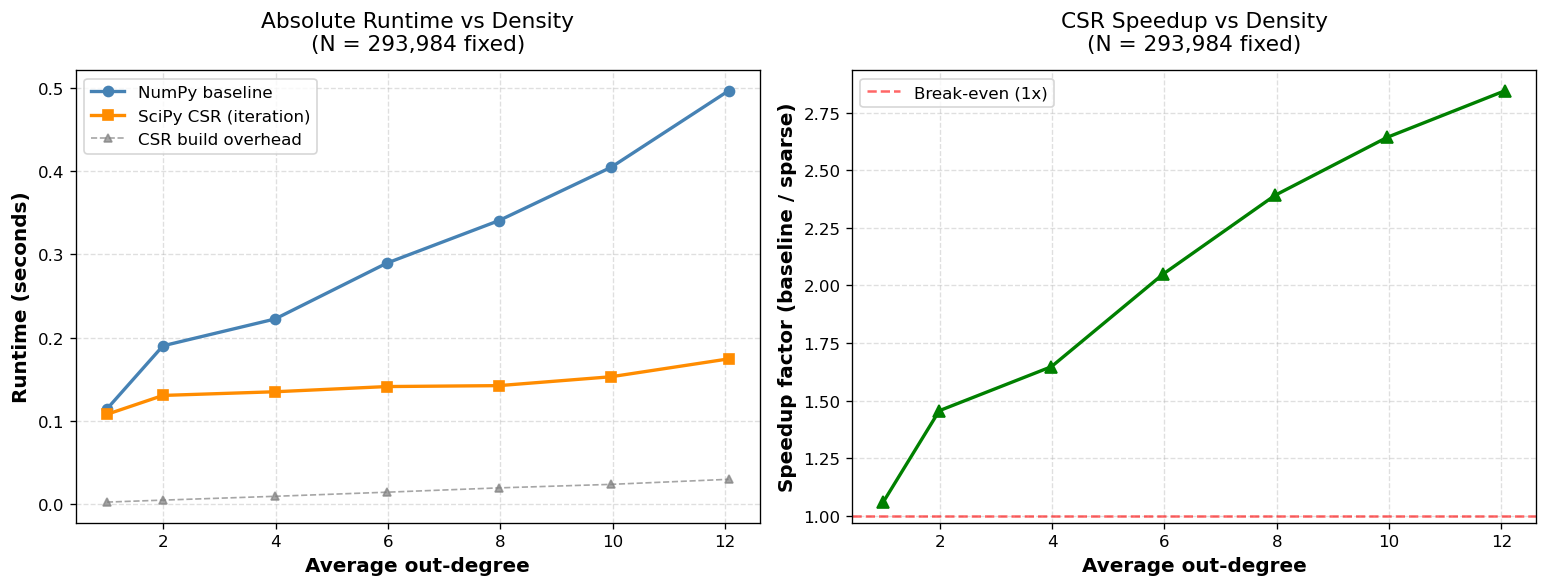

In [10]:
d_outs  = [r[0] for r in density_rows]
t_b_d   = [r[3] for r in density_rows]
t_s_d   = [r[4] for r in density_rows]
t_bld_d = [r[5] for r in density_rows]
sp_d    = [r[6] for r in density_rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

ax1.plot(d_outs, t_b_d,   "o-",  color="steelblue",  linewidth=2, markersize=6, label="NumPy baseline")
ax1.plot(d_outs, t_s_d,   "s-",  color="darkorange", linewidth=2, markersize=6, label="SciPy CSR (iteration)")
ax1.plot(d_outs, t_bld_d, "^--", color="gray",       linewidth=1, markersize=5, label="CSR build overhead", alpha=0.7)
ax1.set_xlabel("Average out-degree",  fontsize=12, fontweight="bold")
ax1.set_ylabel("Runtime (seconds)",   fontsize=12, fontweight="bold")
ax1.set_title("Absolute Runtime vs Density\n(N = 293,984 fixed)", fontsize=13, pad=12)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.4)

ax2.plot(d_outs, sp_d, "^-", color="green", linewidth=2, markersize=7)
ax2.axhline(y=1, color="red", linestyle="--", alpha=0.6, label="Break-even (1x)")
ax2.set_xlabel("Average out-degree",                       fontsize=12, fontweight="bold")
ax2.set_ylabel("Speedup factor (baseline / sparse)",       fontsize=12, fontweight="bold")
ax2.set_title("CSR Speedup vs Density\n(N = 293,984 fixed)", fontsize=13, pad=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Analysis: What Density Tells Us

With $N$ fixed, the table isolates the effect of edge density on both runtimes and the speedup factor.

**Baseline runtime grows sub-linearly with density.**
From avg out-degree 1 to 12.1 (a 12× increase in edges), the baseline only grows from 0.11s to 0.49s (~4.4×). 
This is because each iteration also pays fixed O(N) costs — allocating `x_next = np.zeros(N)` and computing `x[dangling].sum()` — that do not scale with edge count. 
At low density these fixed costs dominate; at high density the scatter-add dominates.

**Sparse iteration stays nearly flat.**
From avg out-degree 1 to 12.1, sparse iteration time only goes from 0.10s to 0.17s — barely a 1.7× increase for 12× more edges. 
BLAS routines exploit CPU vectorisation so efficiently that the additional non-zeros add very little overhead. 
The build time grows proportionally with edges (0.002s → 0.031s) but stays negligible relative to the iteration cost.

**Speedup grows monotonically with density.**
At very low density (avg out-degree ≈ 1), almost every node is dangling — the algorithms spend most of their time on the dangling-mass correction (an O(N) operation both handle similarly) rather than on link propagation, so there is little room for BLAS to help. 
As density grows, link propagation dominates and the BLAS advantage compounds.

**Key takeaway.**
The CSR advantage is fundamentally a density effect: the sparser the graph, the less benefit BLAS provides, because fixed per-iteration overheads dominate. 
On the real Wikipedia graph (avg out-degree 12.1), density is high enough that sparse CSR is consistently ~2.8× faster than the NumPy baseline, independent of graph size.